<a href="https://colab.research.google.com/github/miamackk/Foundations-Of-Computer-Vision-Code/blob/main/16_Fourier_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt
import math
import cv2
from google.colab import drive
drive.mount('/content/drive')
# from scikit-image import rgb2gray

Mounted at /content/drive


#Chapter 16- Fourier Transform

NOTICE: to run the code, copy the following images folder to your google drive and adjust the image paths below

 https://drive.google.com/drive/folders/1dKo9NOg-ViVJjzil_89kKuiAn0l_cunZ?usp=sharing

In [ ]:
#block image
img = cv2.imread('/content/drive/MyDrive/Foundations Of Computer Vision Code/Chapter 16/images/block.png', cv2.IMREAD_GRAYSCALE)

#for figure 16.10
img1 = cv2.imread('/content/drive/MyDrive/Foundations Of Computer Vision Code/Chapter 16/images/16-1.png', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('/content/drive/MyDrive/Foundations Of Computer Vision Code/Chapter 16/images/16-2.png', cv2.IMREAD_GRAYSCALE)
img3 = cv2.imread('/content/drive/MyDrive/Foundations Of Computer Vision Code/Chapter 16/images/16-3.png', cv2.IMREAD_GRAYSCALE)
img4 = cv2.imread('/content/drive/MyDrive/Foundations Of Computer Vision Code/Chapter 16/images/16-4.png', cv2.IMREAD_GRAYSCALE)
img5 = cv2.imread('/content/drive/MyDrive/Foundations Of Computer Vision Code/Chapter 16/images/16-5.png', cv2.IMREAD_GRAYSCALE)
img6 = cv2.imread('/content/drive/MyDrive/Foundations Of Computer Vision Code/Chapter 16/images/16-6.png', cv2.IMREAD_GRAYSCALE)

# for 16.7.3 seperability
building = cv2.imread('/content/drive/MyDrive/Foundations Of Computer Vision Code/Chapter 16/images/building.jpg')

# for 16.7.6 shift property
buildings = cv2.imread('/content/drive/MyDrive/Foundations Of Computer Vision Code/Chapter 16/images/buildings.png')
buildings_shifted = cv2.imread('/content/drive/MyDrive/Foundations Of Computer Vision Code/Chapter 16/images/buildings_shifted.png')

# for 16.7.7 Modulation, Translation in Frequency

stop_sign = cv2.imread('/content/drive/MyDrive/Foundations Of Computer Vision Code/Chapter 16/images/stop_sign.png', cv2.IMREAD_GRAYSCALE)
stripes = cv2.imread('/content/drive/MyDrive/Foundations Of Computer Vision Code/Chapter 16/images/stripes.png', cv2.IMREAD_GRAYSCALE)

# for figure 16.14, swapping phase and magnitude
stop_sign_2 = cv2.imread('/content/drive/MyDrive/Foundations Of Computer Vision Code/Chapter 16/images/stop_sign_2.png')
sailboat = cv2.imread('/content/drive/MyDrive/Foundations Of Computer Vision Code/Chapter 16/images/sailboat.png')

# for mit building
mit = cv2.imread('/content/drive/MyDrive/Foundations Of Computer Vision Code/Chapter 16/images/mit_bldg.jpg')

# 16.3 Fourier Series

French mathematician Joseph Fourier proposed that any periodic signal could be written as an infinite sum of trigonometric functions

To show this concept, we will show how the ramp function (pictured below) can be recreated as a combonation of sine functions

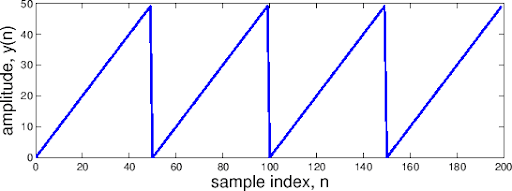

In [ ]:
t = np.arange(-4*np.pi, 4*np.pi, 0.1)

y = np.sin(t)
y2 = (-1/2)* np.sin(2*t)
y3 = (1/3) * np.sin(3*t)
y4 = (-1/4) * np.sin(4*t)
y5 = (1/5) * np.sin(5*t)
y6 = (-1/6) * np.sin(6*t)
y7 = (1/7) * np.sin(7*t)
y8 = (-1/8) * np.sin(8*t)
y9 = (1/9) * np.sin(9*t)
y10 = (-1/10) * np.sin(10*t)

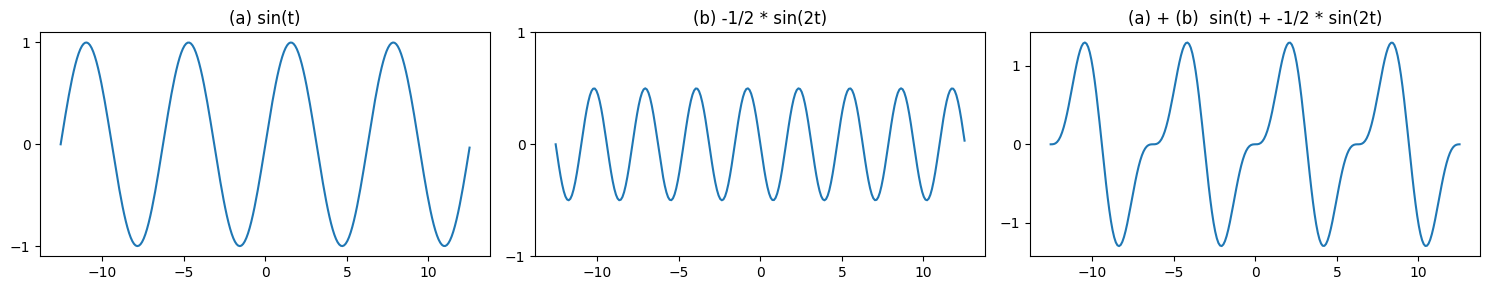

In [ ]:
# @title
functions=[y, y2, y+y2 ]
labels = ["(a) sin(t)", "(b) -1/2 * sin(2t)", "(a) + (b)  sin(t) + -1/2 * sin(2t)"]

fig, axes = plt.subplots(1, 3, figsize=(15, 3))

for i in range(3):
  axes[i].plot(t, functions[i])
  axes[i].set_title(labels[i])
  axes[i].set_yticks([-1, 0, 1])

plt.tight_layout()
plt.show()

The plots above are the result of adding y = sin(t) to y = -(1/2) * sin(2t). But, let's see what happens if we add more sin functions:

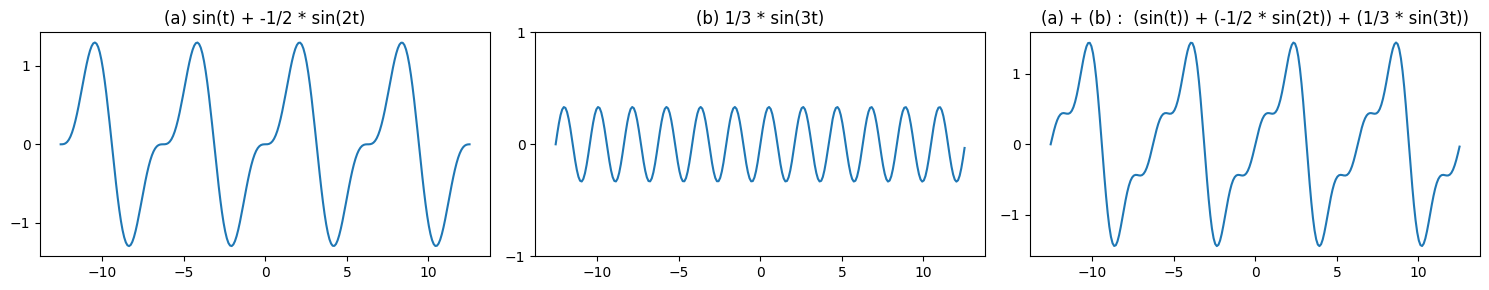

In [ ]:
# @title
functions=[y+y2, y3, y+y2+y3 ]
labels = ["(a) sin(t) + -1/2 * sin(2t)", "(b) 1/3 * sin(3t)", "(a) + (b) :  (sin(t)) + (-1/2 * sin(2t)) + (1/3 * sin(3t))"]

fig, axes = plt.subplots(1, 3, figsize=(15, 3))

for i in range(3):
  axes[i].plot(t, functions[i])
  axes[i].set_title(labels[i])
  axes[i].set_yticks([-1, 0, 1])

plt.tight_layout()
plt.show()

If you look back at the ramp function at the beginning, we can see that our sum of sin functions is looking more and more like the ramp function. This time, we will add 10 sine functions together and see what it looks like

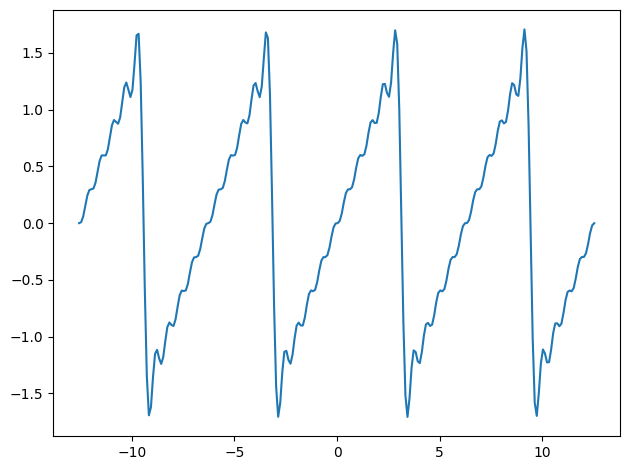

In [ ]:
# @title
plt.plot(t, y+y2+y3+y4+y5+y6+y7+y8+y9+y10)

plt.tight_layout()
plt.show()

As we can see, it is getting even closer to the ramp function and will continue to look more and more similar as we add more sine functions. Eventually, it will end up being the same as the original ramp function, and this is exactly what Fourier was saying!

Because it ends up making up the original function, we want to think of this as merely a change of representation for the ramp function. If the ramp function is f(t), then the fourier series representation is an infinite sequence of coefficients.

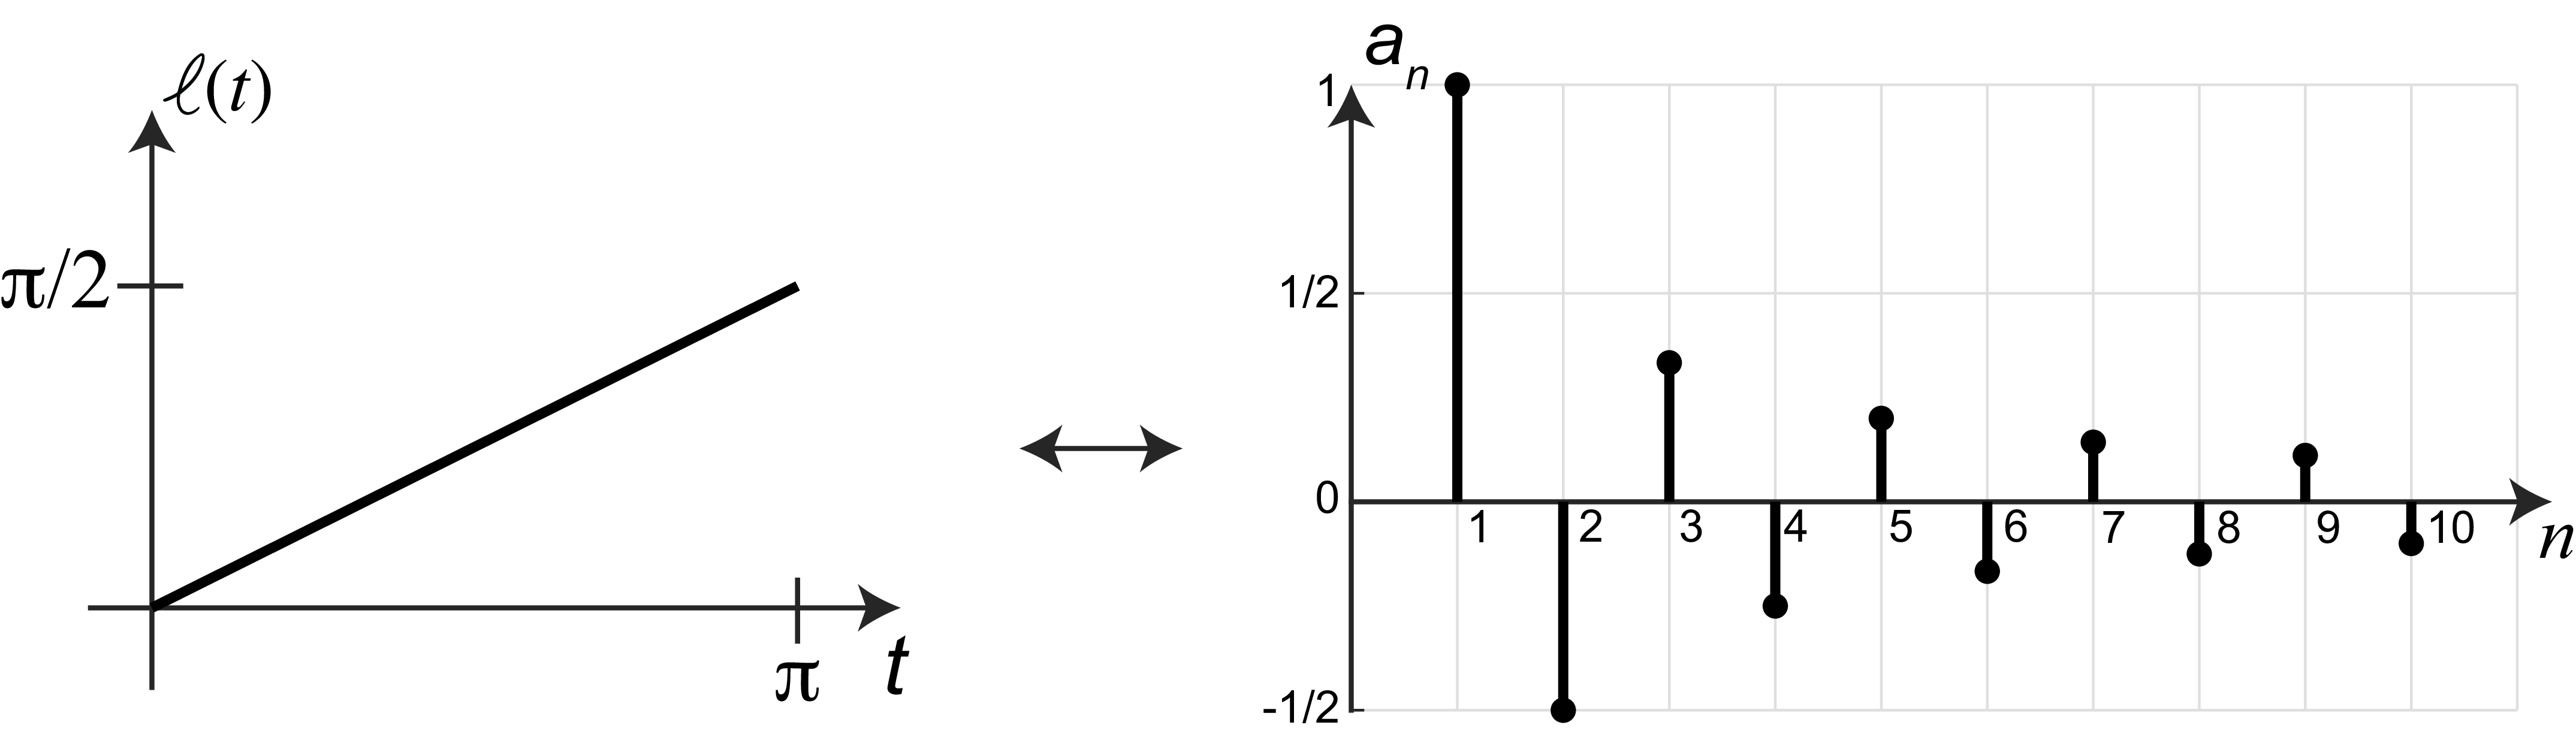

## 16.4 Continuous and Discrete Waves

Sine (and cosine) waves can be discrete or continuous. The discrete time sine wave, which is the one we typically will be dealing with, is as follows: 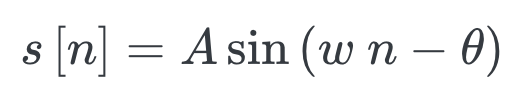

But, the discrete sine wave will not be periodic for any arbitrary value of w. You can find more explanation in the book, but because of this we must make explicit the periodicity of the wave, so we use the form:

 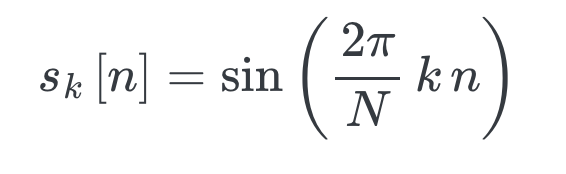

 The same goes for the cosine wave. Below are some examples showing how adjusting k changes the functions.

In [ ]:
n = np.arange(0, 20)

k = 1
x_s = np.sin(((2*np.pi)/20)*k*n)
x_c = np.cos(((2*np.pi)/20)*k*n)

k = 2
x2_s = np.sin(((2*np.pi)/20)*k*n)
x2_c = np.cos(((2*np.pi)/20)*k*n)

k = 3
x3_s = np.sin(((2*np.pi)/20)*k*n)
x3_c = np.cos(((2*np.pi)/20)*k*n)

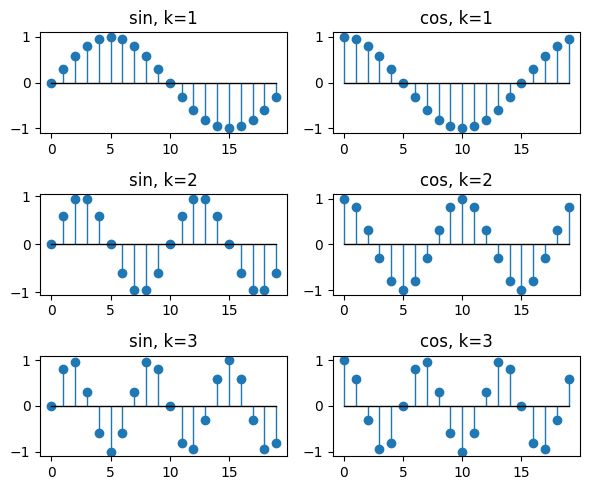

In [ ]:
# @title Figure 16.3
fig, axes = plt.subplots(3, 2, figsize=(6, 5))

data = [
    (x_s, "sin, k=1"), (x_c, "cos, k=1"),
    (x2_s, "sin, k=2"), (x2_c, "cos, k=2"),
    (x3_s, "sin, k=3"), (x3_c, "cos, k=3")
]

for i in range(3):
    for j in range(2):
        idx = i * 2 + j
        markerline, stemlines, baseline = axes[i, j].stem(n, data[idx][0])

        stemlines.set_linewidth(1)
        baseline.set_color('black')
        baseline.set_linewidth(1)

        axes[i, j].set_title(data[idx][1])

plt.tight_layout()
plt.show()

# 16.4.1 Sines and Cosines in 2D

The same analysis can be extended to two dimensions (2D). In 2D, the discrete sine and cosine waves are as follows: 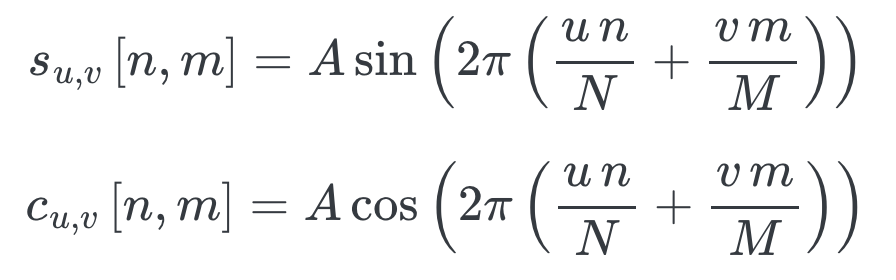

In [ ]:
N, M = 20, 20

x = np.arange(0, 20, 1)

n, m = np.meshgrid(x, x)

u,v = 2, 0
grating_1 = np.sin(2*np.pi*((u*n/N)+(v*m/M)))

u,v = 3, -1
grating_2 = np.sin(2*np.pi*((u*n/N)+(v*m/M)))

u,v = 7, 5
grating_3 = np.sin(2*np.pi*((u*n/N)+(v*m/M)))

<Figure size 640x480 with 0 Axes>

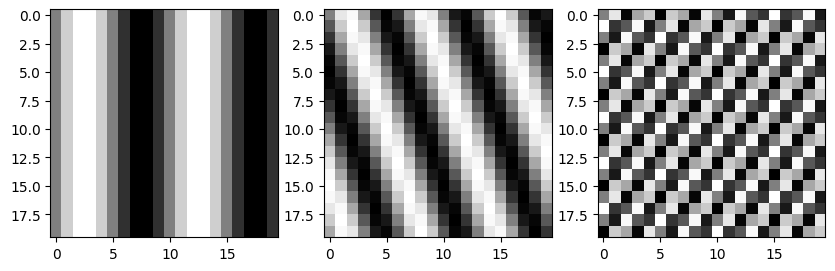

In [ ]:
# @title Figure 16.4
plt.set_cmap("gray")
plt.figure(figsize=(10, 5))

plt.subplot(1,3,1)
plt.imshow(grating_1)

plt.subplot(1,3,2)
plt.imshow(grating_2)

plt.subplot(1,3,3)
plt.imshow(grating_3)

as we move onto the fourier transform for this 2d signal, I recommend reading and trying to understand this: https://dsp.stackexchange.com/questions/34280/image-processing-and-applicability-of-2d-fourier-transform/34282#34282 which gives a basis of understanding for how the different waves start to represent an image.

#16.5  Discrete Fourier Transform

16.5.3 Visualizing the Fourier Transform

As we said before, the Fourier Transformation is just a change in representation. The DFT results in a complex representation, there are two possible ways of writing the result. Using the real and imaginary components:
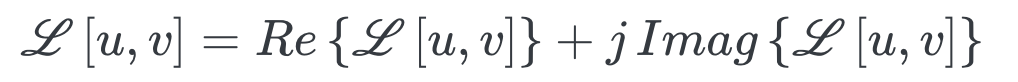

Here is what the real and imaginay representations look, where the images are split into their real and imaginary components :

In [ ]:
fft = np.fft.fftshift(np.fft.fft2(img)) #shift & center the zero frequency

# Extract real and imaginary components
real_part = np.real(fft)
imag_part = np.imag(fft)

#since everything is grouped around center, we need to nromalize it to actually see the values in the middle
def percentile_normalize(arr, lower=2, upper=99):
    vmin, vmax = np.percentile(arr, [lower, upper])
    return np.clip((arr - vmin) / (vmax - vmin), 0, 1)

norm_real = percentile_normalize(real_part)
norm_imag = percentile_normalize(imag_part)

(np.float64(-0.5), np.float64(63.5), np.float64(62.5), np.float64(-0.5))

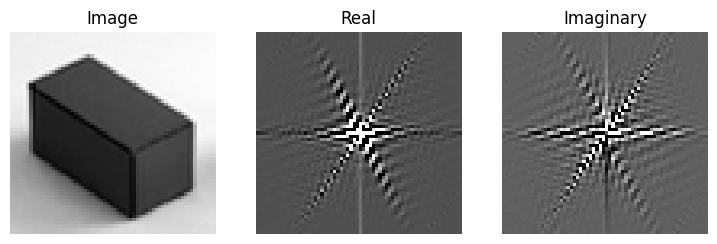

In [ ]:
# @title Figure 16.7
#plot everything

plt.figure(figsize=(9,3))

plt.subplot(1, 3, 1)
plt.title("Image")
plt.imshow(img)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Real")
plt.imshow(norm_real)
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Imaginary")
plt.imshow(norm_imag)
plt.axis("off")

Or we can view the transformation as its polar decomposition:
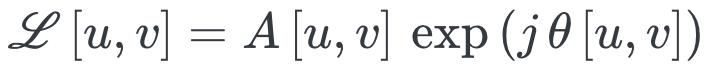

Here is what the polar decomposition looks like, where the image is split into its **amplitude** and **phase** :

In [ ]:
#fourier transform of block image
img_f = np.fft.fftshift(np.fft.fft2(img))

#take magnitude and phase of blocks fourier
mag = np.abs(img_f)
phase = np.angle(img_f)

mag_norm = percentile_normalize(mag)

(np.float64(-0.5), np.float64(63.5), np.float64(62.5), np.float64(-0.5))

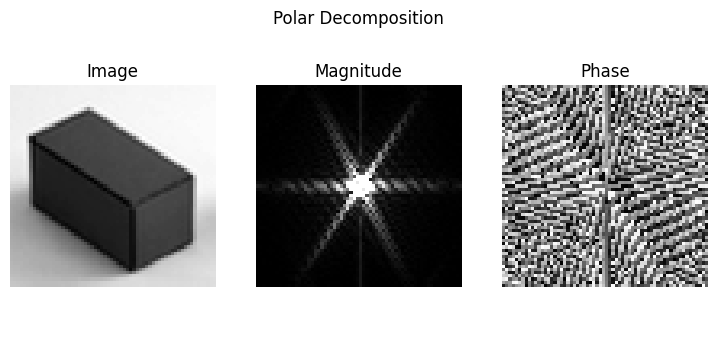

In [ ]:
# @title Figure 16.7
#plot everything
plt.figure(figsize=(9,4))
plt.title("Polar Decomposition")
plt.axis("off")

plt.subplot(1, 3, 1)
plt.title("Image")
plt.imshow(img)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Magnitude")
plt.imshow(mag_norm)
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Phase")
plt.imshow(phase)
plt.axis("off")

To help gain insight into how one can synthesize any image as a sum of sines and cosines, the following figure shows partial sums of the Fourier components of an image. In each partial sum of components, we use the largest N components of the Fourier transform.

In [ ]:
# get fft
fft = np.fft.fftshift(np.fft.fft2(img))

# create distance map from center
rows, cols = img.shape
crow, ccol = rows // 2, cols // 2
y, x = np.ogrid[:rows, :cols]
dist = np.sqrt((x - ccol)**2 + (y - crow)**2)

#sort  pixel positions by distance from center
flat_dist = dist.flatten()
sorted_indices = np.argsort(flat_dist)  # indices of freq components, nearest first

steps = [1, 3, 7, 15, 31, 63, 127, 255, 511, 1023, 2047, 4095]
store_steps = []

for i, n in enumerate(steps):
    #mask to keep only lowest-frequency components
    mask = np.zeros(rows * cols, dtype=bool)
    mask[sorted_indices[:n]] = True
    mask = mask.reshape(rows, cols)

    #apply mask in frequency domain
    Fmasked = fft * mask

    #append to list so that we can display
    store_steps.append(Fmasked)

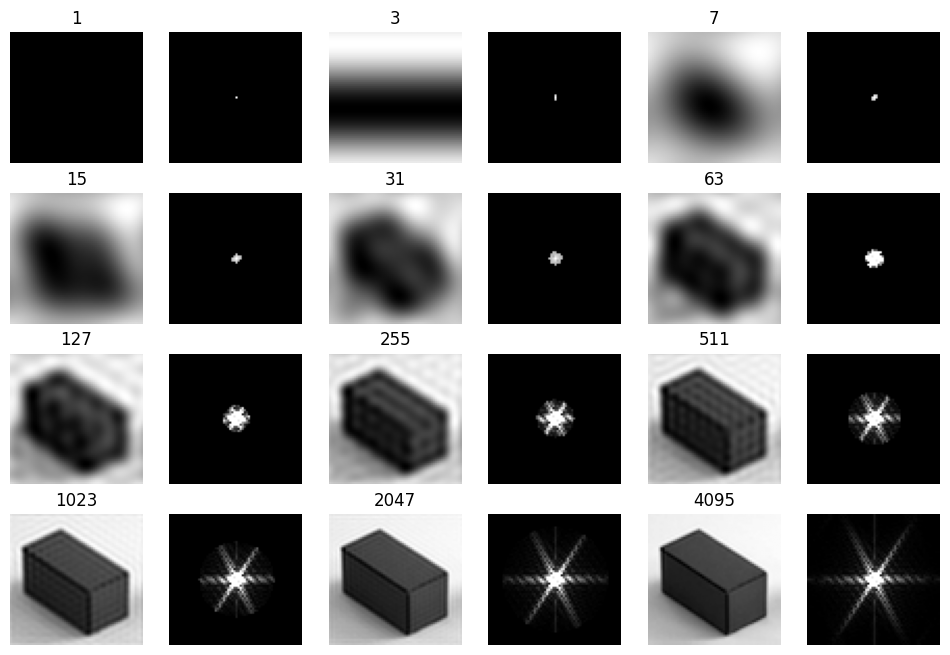

In [ ]:
# @title Figure 16.8
plt.figure(figsize = (12, 8))

for i in range(12):

  plt.subplot(4, 6, 1 + (2*i))
  plt.axis("off")
  plt.title(f"{steps[i]}")
  plt.imshow(np.abs(np.fft.ifft2(np.fft.ifftshift(store_steps[i]))))


  plt.subplot(4, 6, 2 + (2*i))
  plt.axis("off")
  if i<5:
    plt.imshow(np.log1p(np.abs(store_steps[i])))
  else:
    plt.imshow(percentile_normalize(np.abs(store_steps[i])))


# DFT of several waves with different frequencies and orientations.

The following figure (Figure 16.9) shows the DFT of several waves with different frequencies and orientations.


In [ ]:
N, M = 64, 64

x = np.arange(0, 64, 1)

n, m = np.meshgrid(x, x)

u,v = 1, -2
img_1 = np.sin(2*np.pi*((u*n/N)+(v*m/M)))

u,v = 5, 0
img_2 = np.sin(2*np.pi*((u*n/N)+(v*m/M)))

u,v = 10, -7
img_3 = np.sin(2*np.pi*((u*n/N)+(v*m/M)))

u,v = 11, 15
img_4 = np.sin(2*np.pi*((u*n/N)+(v*m/M)))

img_5 = img_2 + img_3

u,v = 14,-7
test1 = np.sin(2*np.pi*((u*n/N)+(v*m/M)))
u,v = 6,-7
test2 = np.sin(2*np.pi*((u*n/N)+(v*m/M)))
img_6 = test2 + test1

<Figure size 640x480 with 0 Axes>

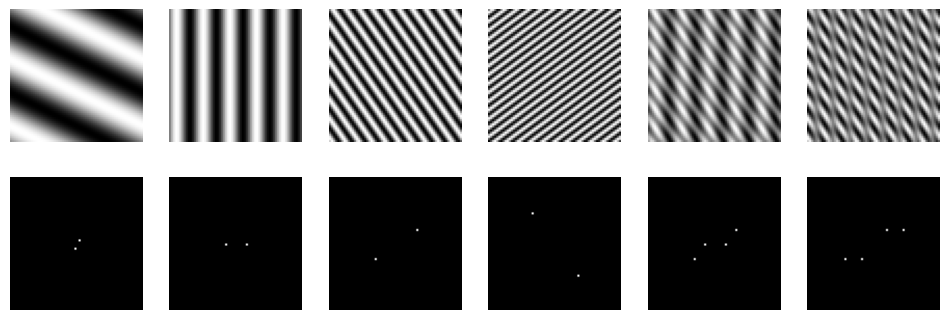

In [ ]:
# @title Figure 16.9
plt.set_cmap("gray")
plt.figure(figsize=(12, 4))

images = [img_1, img_2, img_3, img_4, img_5, img_6]

for i in range(12):
  plt.subplot(2,6,i+1)
  plt.axis("off")
  if i <= 5:
    plt.imshow(images[i])
  else:
    plt.imshow(np.abs(np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(images[i-6])))))

# Two-dimensional Fourier transform pairs

 Below are some two-dimensional Fourier transform pairs. Note the trends visible in the collection of transform pairs: As the support of the image in one domain gets larger, the magnitude in the other domain becomes more localized.

In [ ]:
images = [img1, img2, img3, img4, img5, img6]
ft_images = [None, None, None, None, None, None]

for i in range(6):
  ft_images[i] = np.fft.fftshift(np.fft.fft2(images[i]))


<Figure size 640x480 with 0 Axes>

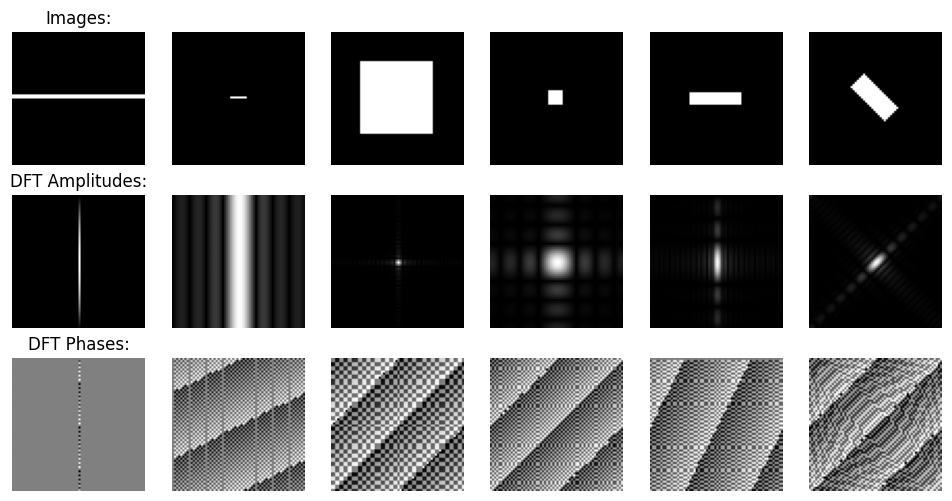

In [ ]:
# @title Figure 16.10
plt.set_cmap("gray")
plt.figure(figsize=(12, 6))

for i in range(18):
  plt.subplot(3,6,i+1)
  plt.axis("off")
  if i <= 5:
    plt.imshow(images[i])
  elif i <= 11:
    plt.imshow(np.abs(ft_images[i-6]))
  else:
    plt.imshow(np.angle(ft_images[i-12]))

  if i == 0:
    plt.title("Images:")
  elif i == 6:
    plt.title("DFT Amplitudes:")
  elif i == 12:
    plt.title("DFT Phases:")

# 16.6.3 Box Function

In [ ]:
box = np.zeros(32)
box[0:6]=1
box[26:]=1

stacked = np.hstack((box, box, box, box)) #manually creating my box values

x = np.arange(-40, 40)
y = stacked[24: 104]


fft_box = (np.fft.fft(box))
fft_stacked = np.hstack((fft_box, fft_box, fft_box, fft_box))
y2 = fft_stacked[24: 104]



/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.12/dist-packages/numpy/ma/core.py:3413: ComplexWarning: Casting complex values to real discards the imaginary part
  _data[indx] = dval
/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


<StemContainer object of 3 artists>

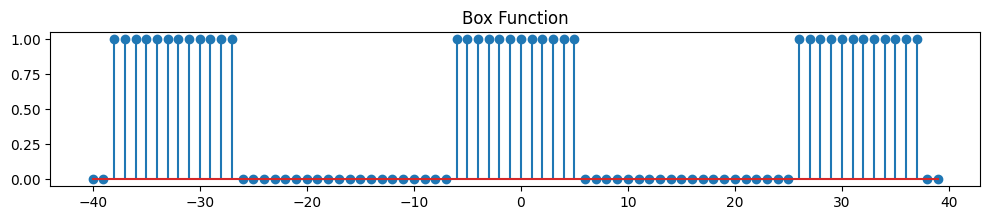

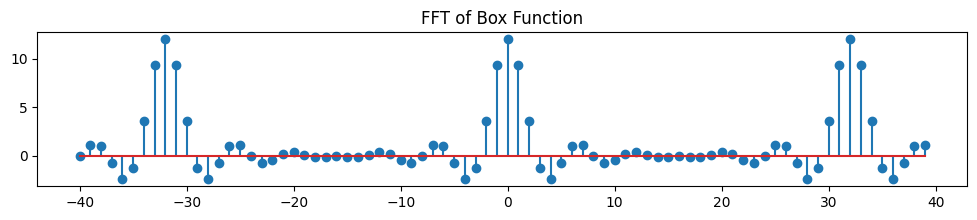

In [ ]:
# @title Figure 16.11
# create the stem plot
plt.figure(figsize=(12,2))
plt.stem(x, y)
plt.title("Box Function")

plt.figure(figsize=(12,2))
plt.title("FFT of Box Function")
x = np.arange(-40, 40)
plt.stem(x, y2)


# 16.7.2 Separability

A 2D image f(x, y) is separable if it can be written as:
f(x, y) = g(x) * h(y)

Basically this just means that it's just the outer product of two 1D signals: one describing horizontal variation and one describing vertical variation. If an image is separable, then its Fourier transform is separable.


In [ ]:
channels = []

for i in range(3):
  U, S, Vt = np.linalg.svd(building[:,:,i], full_matrices=False)
  # Rank-1 (separable) approximation
  rank = 1
  channels.append(S[0] * np.outer(U[:, 0], Vt[0, :]))

  row_signal = U[:, 0]        # vertical pattern
  col_signal = S[0] * Vt[0, :]  # horizontal pattern

separable = cv2.merge((channels[2], channels[1], channels[0]))
normalized_image = (separable - np.min(separable)) / (np.max(separable) - np.min(separable))

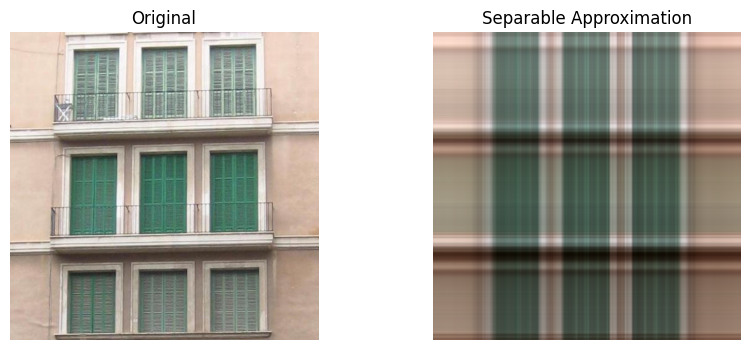

In [ ]:
# @title
# Plot
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(cv2.cvtColor(building, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(normalized_image)
axes[1].axis("off")
axes[1].set_title("Separable Approximation")
plt.show()

# Verify: the approximation IS separable by construction
# because it equals outer(row_signal, col_signal)
# print("Is separable:", np.allclose(normalized_image, np.outer(U[:,0], S[0]*Vt[0,:])))

# 16.7.6 Shift Property, Translation in Space

A shift corresponds to a translation in space. This is a very common operation that has a very particular influence on the Fourier transform of the signal. It turns out that translating a signal in the spatial domain, results in multiplying its Fourier transform by a complex exponential.

In [ ]:
buildings_gray = cv2.cvtColor(buildings, cv2.COLOR_BGR2GRAY)
shifted_gray = cv2.cvtColor(buildings_shifted, cv2.COLOR_BGR2GRAY)

fft = np.fft.fftshift(np.fft.fft2(buildings_gray)) #shift & center the zero frequency
fft_shift = np.fft.fftshift(np.fft.fft2(shifted_gray)) #shift & center the zero frequency

# Extract real component from first image
real_part = np.real(fft)

#do the same for shifted image
real_shift = np.real(fft_shift)

#divided
div = fft_shift/fft
real_div = np.real(div)

ratio = fft_shift / (fft + 1e-10)
ifft_shifted = np.fft.fftshift((np.fft.ifft2(np.fft.fftshift(ratio))))


(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

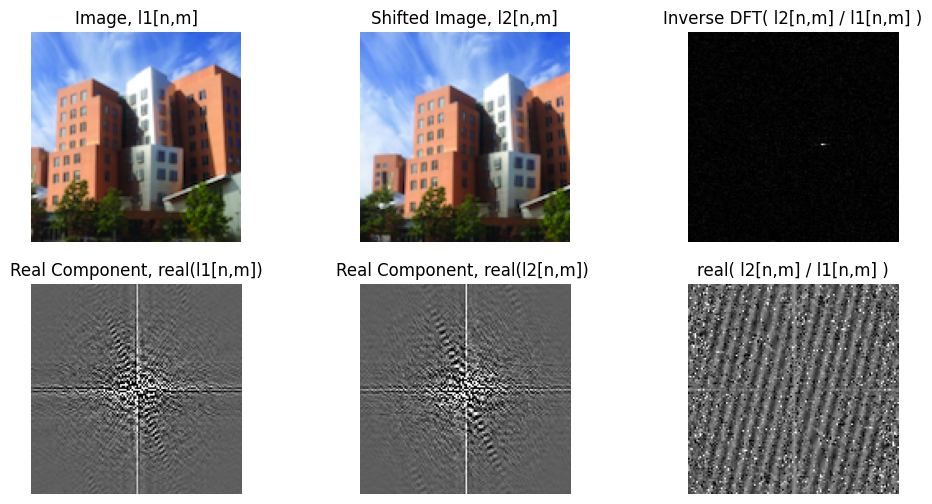

In [ ]:
# @title Figure 16.12
plt.figure(figsize=(12, 6))

plt.subplot(2,3,1)
plt.title("Image, l1[n,m]")
plt.imshow(cv2.cvtColor(buildings, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(2,3,2)
plt.title("Shifted Image, l2[n,m]")
plt.imshow(cv2.cvtColor(buildings_shifted, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(2,3,3)
plt.title("Inverse DFT( l2[n,m] / l1[n,m] )")
plt.imshow(np.abs(ifft_shifted), cmap="gray")
plt.axis("off")

plt.subplot(2,3,4)
plt.title("Real Component, real(l1[n,m])")
plt.imshow(percentile_normalize(real_part), cmap="gray")
plt.axis("off")

plt.subplot(2,3,5)
plt.title("Real Component, real(l2[n,m]) ")
plt.imshow(percentile_normalize(real_shift), cmap="gray")
plt.axis("off")

plt.subplot(2,3,6)
plt.title("real( l2[n,m] / l1[n,m] )")
plt.imshow(percentile_normalize(real_div), cmap="gray")
plt.axis("off")

The second image is the first image but shifted 16 pixels to the right and 4 down. Looking at the Inverse DFT of image 2 divided by image 1, the impulse is located 16 pixels to the right and 4 pixels down from the middle.

# 16.7.7 Modulation, Translation in Frequency

If we multiply an image with a complex exponential, its Fourier transform is translated, a property related to the shifting we saw previously. Multiplying a signal by a wave, signal modulation, is one of the basic operations in communications. The following figure shows an example of modulating an image of a stop sign by multiplying by diagonal wave. The bottom row shows the corresponding Fourier transforms.

In [ ]:
# @title
def normalize_img(img):
    img = img - img.min()
    img = img / img.max()
    return img

stop_sign_fft = np.fft.fftshift(np.fft.fft2(stop_sign))

N, M = 419, 419
x = np.arange(0, 419, 1)
n, m = np.meshgrid(x, x)
u,v = 13, 13
stripes = np.sin(2*np.pi*((u*n/N)+(v*m/M)))

n_stripes = normalize_img(stripes) #stripes normalized

stripes_fft = np.fft.fftshift(np.fft.fft2(stripes))

comb_fft = np.fft.fftshift(np.fft.fft2(stop_sign * stripes))

ss = normalize_img(stop_sign)


In [ ]:
# @title
# for display purposes
N, M = 128, 128
x = np.arange(0, 128, 1)
n, m = np.meshgrid(x, x)
u,v = 7, 7
stripe = np.sin(2*np.pi*((u*n/N)+(v*m/M)))
stripe_fft = np.fft.fftshift(np.fft.fft2(stripe))

(np.float64(-0.5), np.float64(418.5), np.float64(418.5), np.float64(-0.5))

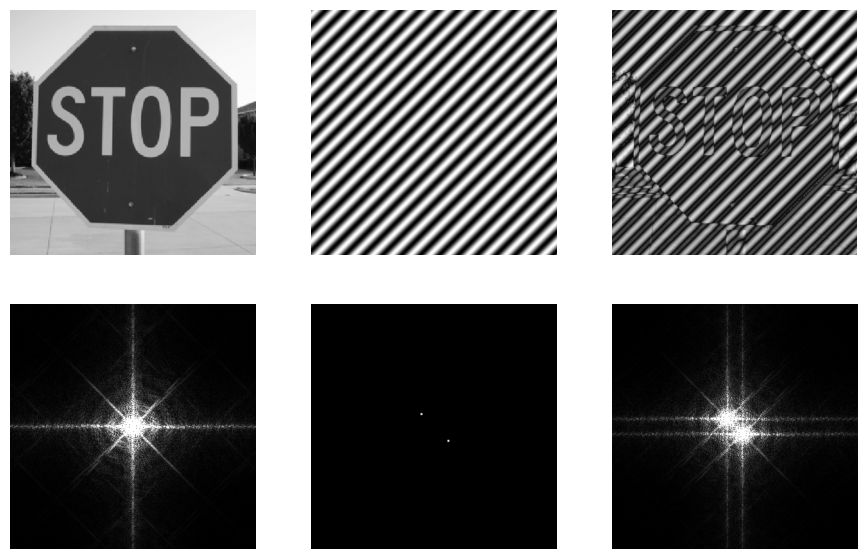

In [ ]:
# @title
plt.figure(figsize=(11, 7))

plt.subplot(2, 3, 1)
plt.imshow(stop_sign, cmap = "gray")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(stripes, cmap = "gray")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(abs(n_stripes-ss), cmap = "gray")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(percentile_normalize(np.abs(stop_sign_fft)), cmap = "gray")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(np.abs(stripe_fft), cmap = "gray")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(percentile_normalize(np.abs(comb_fft)), cmap = "gray")
plt.axis("off")

# 16.9 Fourier Analysis as an Image Representation

Figure 16.14 shows that the phase of the image is what holds most of the structure of the image. Swapping phase and magnitude of images ends up looking like whichever image the phase comes from.

In [ ]:
r_sign, g_sign, b_sign = stop_sign_2[:,:,0], stop_sign_2[:,:,1], stop_sign_2[:,:,2]

In [ ]:
#split sailboat image into r, g, b channels
r_boat, g_boat, b_boat = sailboat[:,:,0], sailboat[:,:,1], sailboat[:,:,2]
#get fft of each channel
fft_r, fft_g, fft_b = np.fft.fftshift(np.fft.fft2(r_boat)), np.fft.fftshift(np.fft.fft2(g_boat)), np.fft.fftshift(np.fft.fft2(b_boat))
#get phase of each channel and merge the channels back together
phase_r_boat, phase_g_boat, phase_b_boat = np.angle(fft_b), np.angle(fft_g), np.angle(fft_r)
phase_sailboat = cv2.merge((phase_r_boat, phase_g_boat, phase_b_boat))
#get amplitude of each channel and merge back together
amp_r_boat, amp_g_boat, amp_b_boat = np.abs(fft_b), np.abs(fft_g), np.abs(fft_r)
amplitude_sailboat = cv2.merge((amp_r_boat, amp_g_boat, amp_b_boat))

#do the same for stop sign image

#split stop sign image into r, g, b channels
r_sign, g_sign, b_sign = stop_sign_2[:,:,0], stop_sign_2[:,:,1], stop_sign_2[:,:,2]
#get fft of each channel
fft_r, fft_g, fft_b = np.fft.fftshift(np.fft.fft2(r_sign)), np.fft.fftshift(np.fft.fft2(g_sign)), np.fft.fftshift(np.fft.fft2(b_sign))
#get phase of each channel and merge the channels back together
phase_r_sign, phase_g_sign, phase_b_sign = np.angle(fft_b), np.angle(fft_g), np.angle(fft_r)
phase_stop_sign = cv2.merge((phase_r_sign, phase_g_sign, phase_b_sign))
#get amplitude of each channel and merge back together
amp_r_sign, amp_g_sign, amp_b_sign = np.abs(fft_b), np.abs(fft_g), np.abs(fft_r)
amplitude_stop_sign = cv2.merge((amp_r_sign, amp_g_sign, amp_b_sign))

In [ ]:
#swap phase and magnitude
#use equation DFT = Amplitude * exp(i * Phase)

#reconstruct channel, inverse shift, inverse fft, take jsut the real part, normalize the image
r = normalize_img(np.real(np.fft.ifft2(np.fft.ifftshift(amp_r_sign * np.exp(1j * phase_r_boat)))))
g = normalize_img(np.real(np.fft.ifft2(np.fft.ifftshift(amp_g_sign * np.exp(1j * phase_g_boat)))))
b = normalize_img(np.real(np.fft.ifft2(np.fft.ifftshift(amp_b_sign * np.exp(1j * phase_b_boat)))))
#merge the r, g, and b channels
boatPhase_signMagnitude = cv2.merge((r, g, b))

# do the same for the other image
r = normalize_img(np.real(np.fft.ifft2(np.fft.ifftshift(amp_r_boat * np.exp(1j * phase_r_sign)))))
g = normalize_img(np.real(np.fft.ifft2(np.fft.ifftshift(amp_g_boat * np.exp(1j * phase_g_sign)))))
g = normalize_img(np.real(np.fft.ifft2(np.fft.ifftshift(amp_b_boat * np.exp(1j * phase_b_sign)))))

signPhase_boatMagnitude = cv2.merge((r, g, b))


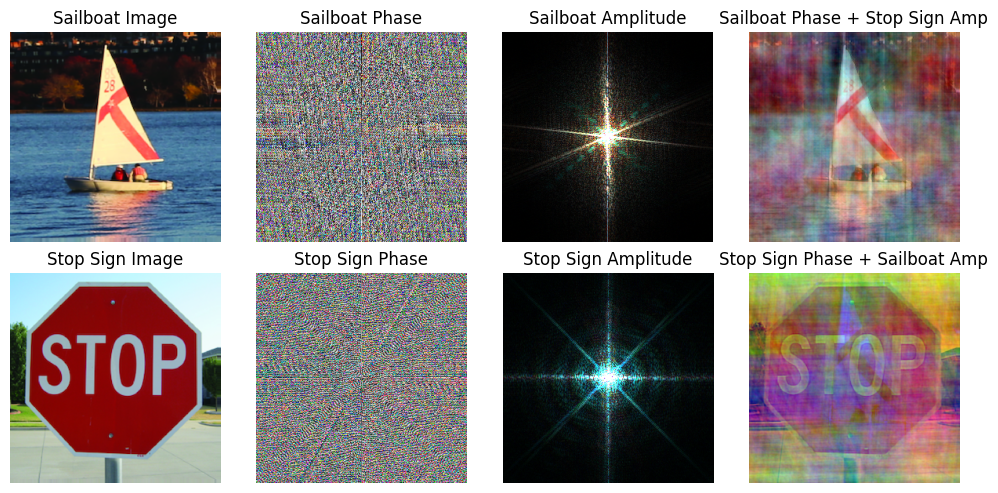

In [ ]:
# @title
plt.figure(figsize = (10, 5))

#sailboat image
plt.subplot(2, 4, 1)
plt.title("Sailboat Image")
plt.imshow(cv2.cvtColor(sailboat, cv2.COLOR_BGR2RGB))
plt.axis("off")

#phase
plt.subplot(2, 4, 2)
plt.title("Sailboat Phase")
plt.imshow(normalize_img(phase_sailboat))
plt.axis("off")

#amplitude
plt.subplot(2, 4, 3)
plt.title("Sailboat Amplitude")
plt.imshow(percentile_normalize(amplitude_sailboat))
plt.axis("off")

#swapped image
plt.subplot(2, 4, 4)
plt.title("Sailboat Phase + Stop Sign Amp")
plt.imshow(boatPhase_signMagnitude)
plt.axis("off")

#stop sign image
plt.subplot(2, 4, 5)
plt.title("Stop Sign Image")
plt.imshow(cv2.cvtColor(stop_sign_2, cv2.COLOR_BGR2RGB))
plt.axis("off")

#phase
plt.subplot(2, 4, 6)
plt.title("Stop Sign Phase")
plt.imshow(normalize_img(phase_stop_sign))
plt.axis("off")

#amplitude
plt.subplot(2, 4, 7)
plt.title("Stop Sign Amplitude")
plt.imshow(percentile_normalize(amplitude_stop_sign))
plt.axis("off")

#swapped image
plt.subplot(2, 4, 8)
plt.title("Stop Sign Phase + Sailboat Amp")
plt.imshow(signPhase_boatMagnitude)
plt.axis("off")

plt.tight_layout()

# 16.10 Fourier Analysis of Linear Filters

When filtering images, low-pass filters will output a blurry picture encoding the coarse elements of the image. A band-pass filter will highlight middle size elements, while the output of a high-pass filter will show the fine details of the image. The three images in the follwoing figure will show the output image processed by these three filters.

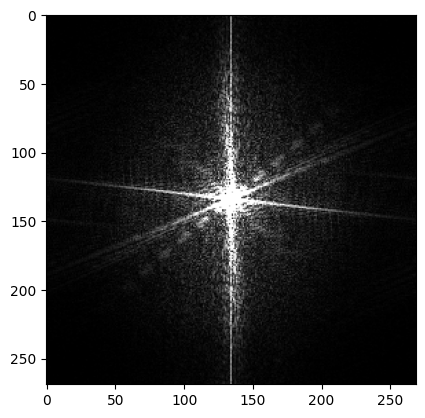

In [ ]:
fft = np.fft.fftshift(np.fft.fft2(sailboat[:,:,0]))

plt.imshow(percentile_normalize(np.abs(fft)))

In [ ]:
r, g, b = sailboat[:,:,2], sailboat[:,:,1], sailboat[:,:,0]
fft_r, fft_g, fft_b = np.fft.fftshift(np.fft.fft2(r)), np.fft.fftshift(np.fft.fft2(g)), np.fft.fftshift(np.fft.fft2(b))

height, width = sailboat.shape[0], sailboat.shape[1]
hheight, hwidth = height//2, width//2
mid_buffer = 15

low_r, low_g, low_b = fft_r.copy(), fft_g.copy(), fft_b.copy()

#FILTER OUT LOW FREQUENCIES (edge detect)
mask = np.ones_like(sailboat[:,:,0])
mask[hheight - mid_buffer : hheight + mid_buffer , hwidth - mid_buffer : hwidth + mid_buffer] = 0

low_r *= mask
low_b *= mask
low_g *= mask

low_masked_fft = cv2.merge((np.abs(low_r), np.abs(low_g), np.abs(low_b)))

r = normalize_img(np.real(np.fft.ifft2(np.fft.ifftshift(low_r))))
g = normalize_img(np.real(np.fft.ifft2(np.fft.ifftshift(low_g))))
b = normalize_img(np.real(np.fft.ifft2(np.fft.ifftshift(low_b))))

high_pass = cv2.merge((r, g, b))

#FILTER OUT HIGH FREQUENCIES (blur image)

buffer = 128

mask2 = np.ones_like(sailboat[:,:,0])
mask2[0:buffer, :]=0
mask2[:, 0:buffer]=0
mask2[height-buffer:, :]=0
mask2[:, width-buffer:]=0

high_r, high_g, high_b = fft_r.copy(), fft_g.copy(), fft_b.copy()

high_r *= mask2
high_g *= mask2
high_b *= mask2

high_masked_fft = cv2.merge((np.abs(high_r), np.abs(high_g), np.abs(high_b)))

r = normalize_img(np.real(np.fft.ifft2(np.fft.ifftshift(high_r))))
g = normalize_img(np.real(np.fft.ifft2(np.fft.ifftshift(high_g))))
b = normalize_img(np.real(np.fft.ifft2(np.fft.ifftshift(high_b))))
low_pass = cv2.merge((r, g, b))

#BAND PASS
mid_buffer = 8
mask1 = np.ones_like(sailboat[:,:,0])
mask1[hheight - mid_buffer : hheight + mid_buffer , hwidth - mid_buffer : hwidth + mid_buffer] = 0

new_buffer = 100
mask2 = np.ones_like(sailboat[:,:,0])
mask2[0:new_buffer, :]=0
mask2[:, 0:new_buffer]=0
mask2[height-new_buffer:, :]=0
mask2[:, width-new_buffer:]=0

mask3 = mask1 + mask2
mask3= 2-mask3

band_r, band_g, band_b = fft_r.copy(), fft_g.copy(), fft_b.copy()

band_r *= mask3
band_g *= mask3
band_b *= mask3

band_masked_fft = cv2.merge((np.abs(band_r), np.abs(band_g), np.abs(band_b)))

r = normalize_img(np.real(np.fft.ifft2(np.fft.ifftshift(band_r))))
g = normalize_img(np.real(np.fft.ifft2(np.fft.ifftshift(band_g))))
b = normalize_img(np.real(np.fft.ifft2(np.fft.ifftshift(band_b))))

band_pass = cv2.merge((r, g, b))


In [ ]:
# @title
#JUST FOR DISPLAY PURPOSES
buffer = 115

mask2 = np.ones_like(sailboat[:,:,0])
mask2[0:buffer, :]=0
mask2[:, 0:buffer]=0
mask2[height-buffer:, :]=0
mask2[:, width-buffer:]=0

high_r, high_g, high_b = fft_r.copy(), fft_g.copy(), fft_b.copy()

high_r *= mask2
high_g *= mask2
high_b *= mask2

high_masked_fft = cv2.merge((np.abs(high_r), np.abs(high_g), np.abs(high_b)))

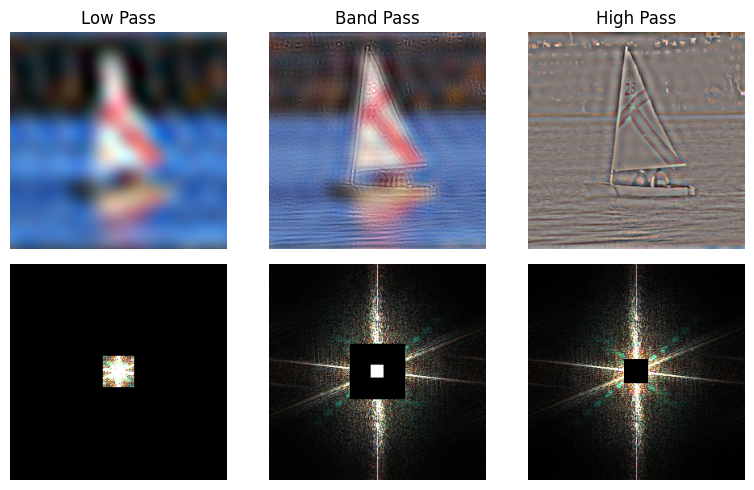

In [ ]:
# @title
plt.figure(figsize = (8,5))

plt.subplot(2, 3, 1)
plt.axis("off")
plt.title("Low Pass")
plt.imshow(low_pass)

plt.subplot(2, 3, 2)
plt.axis("off")
plt.title("Band Pass")
plt.imshow(band_pass)

plt.subplot(2, 3, 3)
plt.axis("off")
plt.title("High Pass")
plt.imshow(high_pass)


plt.subplot(2, 3, 4)
plt.imshow(percentile_normalize(high_masked_fft))
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(percentile_normalize(band_masked_fft))
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(percentile_normalize(low_masked_fft))
plt.axis("off")

plt.tight_layout()

# Removing the columns from MIT building- Figure 16.19

In [ ]:
# @title
import cv2
from google.colab import drive
from skimage.color import rgb2gray
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
mit = cv2.cvtColor(mit, cv2.COLOR_BGR2RGB)
mit_grey = rgb2gray(mit)

mit_fourier = np.fft.fftshift(np.fft.fft2(mit_grey))

magnitude = np.abs(mit_fourier)


fourier = np.fft.fftshift(np.fft.fft2(mit_grey))
rows, cols = mit_grey.shape
rows_2, cols_2 = rows//2, cols//2 #we need these halved values later when creating the mask

stripe_offset = 15 #how far the original bands are apart
width = 3 #width of each band we take out

mask = np.ones_like(fourier, dtype = np.uint8) #making a mask so that i can flip it and get just the columns later

#first two stripes that we take out of the fourier image
mask[:, cols_2 - stripe_offset - width : cols_2 - stripe_offset + width] = 0
mask[:, cols_2 + stripe_offset - width : cols_2 + stripe_offset + width] = 0

for i in range(2, 6):
  offset = i * (stripe_offset - 1) #each stripe is a little closer to the last so i have to account for that as i loop
  mask[:, cols_2 - offset - width : cols_2 - offset + width] = 0
  mask[:, cols_2 + offset - width : cols_2 + offset + width] = 0

fourier_filtered = fourier * mask
just_columns = fourier * np.logical_not(mask).astype(int) #logical not, so that we flip the 1s and 0s in the mask

mit_filtered = np.real(np.fft.ifft2(np.fft.ifftshift(fourier_filtered)))
columns = np.real(np.fft.ifft2(np.fft.ifftshift(just_columns)))

(np.float64(-0.5), np.float64(264.5), np.float64(199.5), np.float64(-0.5))

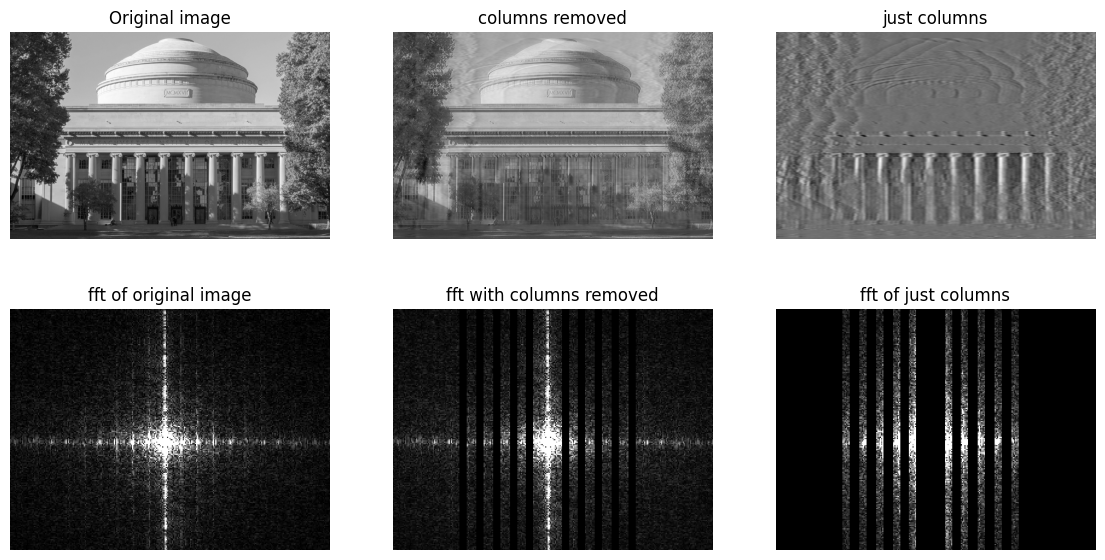

In [ ]:
# @title
plt.figure(figsize=(14,7))

plt.subplot(2, 3, 1)
plt.imshow(mit_grey, cmap='gray')
plt.title("Original image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(mit_filtered, cmap='gray')
plt.title("columns removed")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(columns, cmap='gray')
plt.title("just columns")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(percentile_normalize(np.abs(magnitude[200:400, 350:615])), cmap='gray')
plt.title("fft of original image")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(percentile_normalize(np.abs(fourier_filtered[200:400, 350:615])), cmap='gray')
plt.title("fft with columns removed")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(percentile_normalize(np.abs(just_columns[200:400, 350:615])), cmap='gray')
plt.title("fft of just columns")
plt.axis("off")

